# Project ResNet Ablation Study (Residual Model)

![스크린샷 2026-07-26 223009.png](<attachment:스크린샷 2026-07-26 223009.png>)
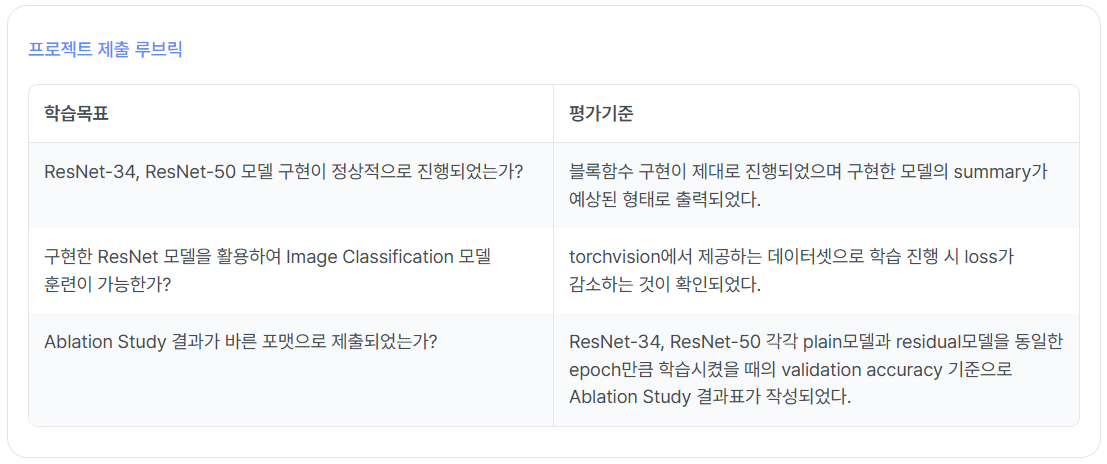

### ResNet-34, ResNet-50 모델 구현이 정상적으로 진행되었는가?

![스크린샷 2026-07-26 230750.png](<attachment:스크린샷 2026-07-26 230750.png>)
![스크린샷 2026-07-26 230826.png](<attachment:스크린샷 2026-07-26 230826.png>)
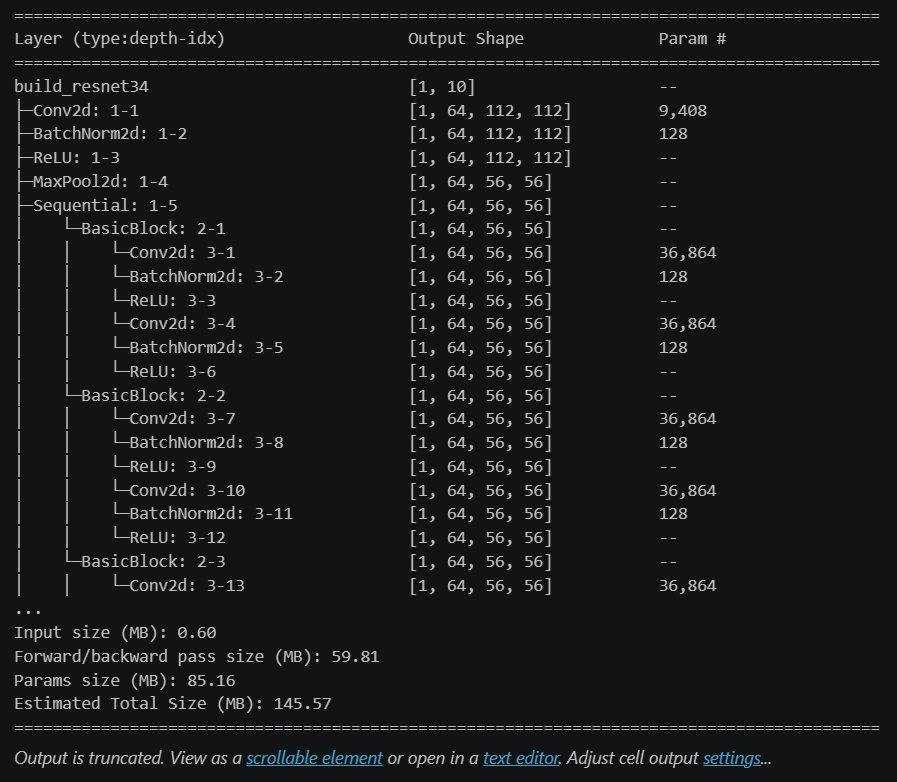
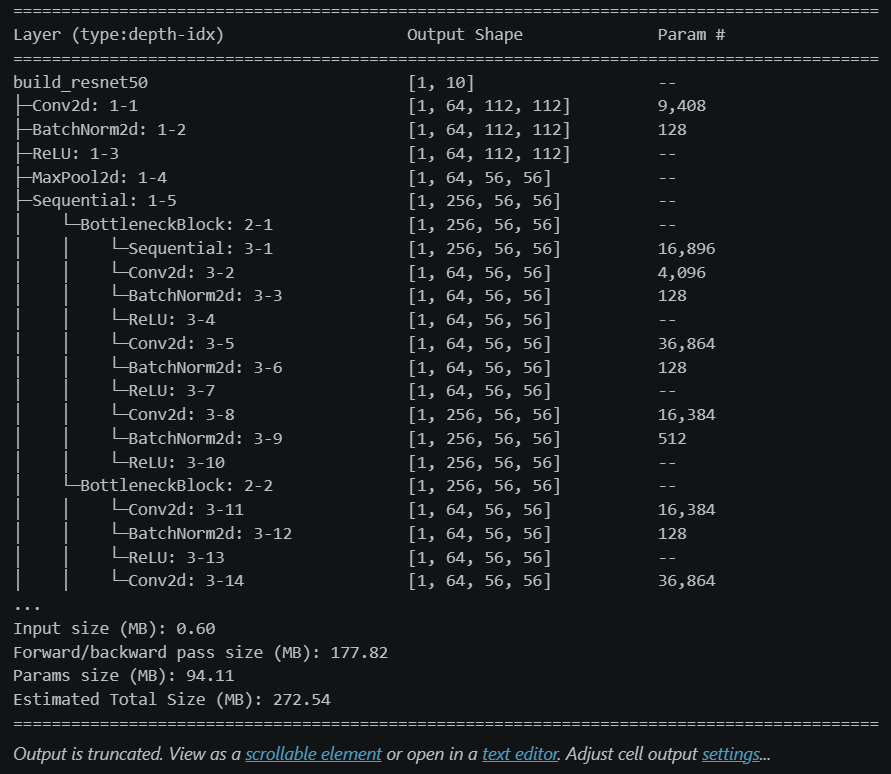

### 구현한 ResNet 모델을 활용하여 Image Classification 모델 훈련이 가능한가?

![스크린샷 2026-07-26 232646.png](<attachment:스크린샷 2026-07-26 232646.png>)
![스크린샷 2026-07-26 232705.png](<attachment:스크린샷 2026-07-26 232705.png>)
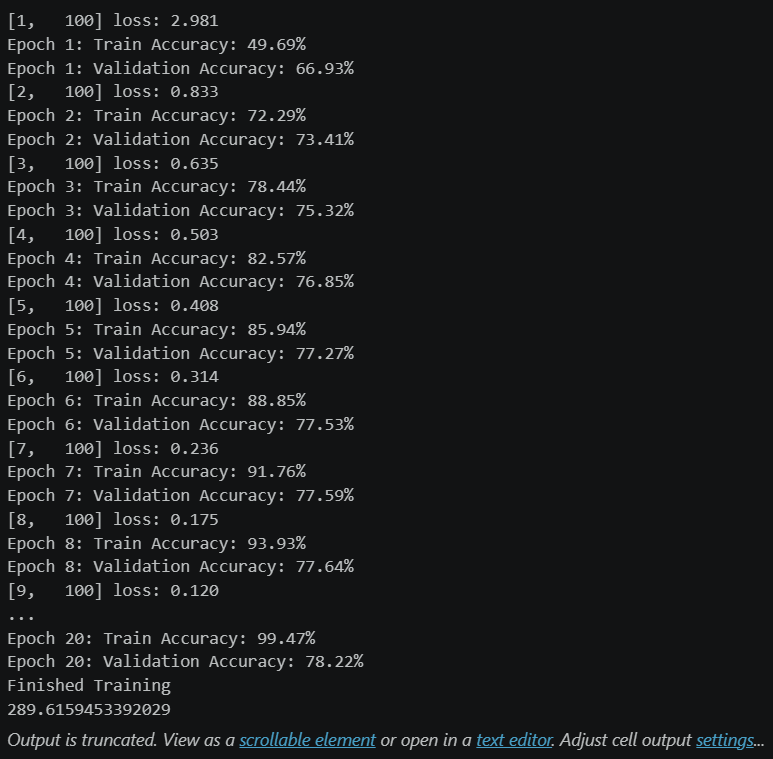
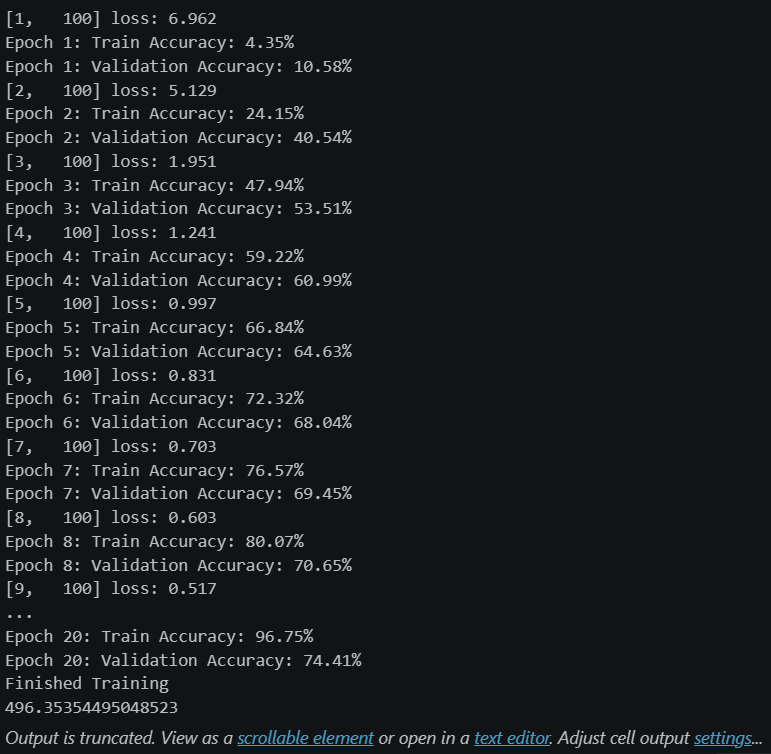

### Ablation Study 결과가 바른 포맷으로 제출되었는가?

| Model | EPOC | Loss | Train Accuracy | Validation Accuracy |
| --- | --- | --- | --- | --- |
| ResNet-34 (Plain) | 20 | 0.018 | 99.47% | 78.22% |
| ResNet-50 (Residual) | 20 | 0.105 | 96.75% | 74.41% |

In [22]:
!nvidia-smi

Sun Jul 26 23:05:38 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 610.62                 KMD Version: 610.62        CUDA UMD Version: 13.3     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   46C    P8              7W /   60W |    2562MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [25]:
import torch, torchvision
print(torch.__version__)
print(torchvision.__version__)
print(torch.cuda.is_available())  # True면 GPU 사용 가능

2.13.0+cu132
0.28.0+cu132
True


In [26]:
# import importlib
# import subprocess
# import sys
import os
# from google.colab import drive

# # Install and import torchinfo
# def install_and_import(package):
#     try:
#         return importlib.import_module(package)
#     except ImportError:
#         subprocess.check_call([sys.executable, "-m", "pip", "install", package])
#         return importlib.import_module(package)

# install_and_import("torchinfo")

# # Google Drive Mount
# # Check if /content/drive exists
# if not os.path.exists('/content/drive'): drive.mount('/content/drive')
# os.chdir('/content/drive/MyDrive/Colab Notebooks')

# CIFAR-10 path
data_path = './data'
train_path = os.path.join(data_path, 'cifar-10-batches-py')

# Pytorch
import torch

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchinfo import summary
# Helper libraries
import numpy as np
import matplotlib.pyplot as plt
import time

In [27]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

#########################################################################################################################
## Is path exists? If not, download the dataset
download_flag = not os.path.exists(train_path)
trainset = torchvision.datasets.CIFAR10(root=data_path, train=True, download=download_flag, transform=transform)
testset = torchvision.datasets.CIFAR10(root=data_path, train=False, download=download_flag, transform=transform)

# # Download CIFAR-10 dataset
# # Way 1
# trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
# testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# # Way 2 Manually download the dataset from https://www.cs.toronto.edu/~kriz/cifar.html and extract it to the data folder
# !mkdir -p data
# !wget --no-check-certificate https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz -O ./data/cifar-10-python.tar.gz
# !cd data && tar -xzf cifar-10-python.tar.gz
##########################################################################################################################

trainloader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=32, shuffle=False)

In [28]:
# 데이터셋을 로드하고 기본 정보를 확인해 보세요.
image, label = trainset[0]

print(f"Image shape: {image.shape}")
print(f"Label: {label}")
print(f"Number of classes: {len(trainset.classes)}")

Image shape: torch.Size([3, 32, 32])
Label: 6
Number of classes: 10


In [29]:
# 데이터의 개수도 확인해 봅시다.
train_size = torch.tensor(len(trainset))
test_size = torch.tensor(len(testset))

print(f"Train dataset size: {train_size} (Shape: {train_size.shape})")
print(f"Test dataset size: {test_size} (Shape: {test_size.shape})")

Train dataset size: 50000 (Shape: torch.Size([]))
Test dataset size: 10000 (Shape: torch.Size([]))


In [30]:
# Q. 이미지의 표현이 0과 1 사이로 들어오도록 직접 Pytorch 정규화 코드를 작성해봅시다.
transform = transforms.Compose([
    transforms.ToTensor()  # uint8 → float32 변환 + 0~1 정규화
])

In [31]:
num_classes = len(trainset.classes)
print(num_classes)

10


In [32]:
class_names = trainset.classes
print(class_names)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [33]:
def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    return np.transpose(npimg, (1, 2, 0))

In [34]:
def show_multiple_images(dataset, n_images=9):
    dataiter = iter(dataset)
    images, labels = next(dataiter)
    fig, axes = plt.subplots(3, 3, figsize=(6, 6))
    axes = axes.flatten()

    for i in range(n_images):
        ax = axes[i]
        img = imshow(images[i])
        ax.imshow(img)
        ax.set_title(f"Label: {trainset.classes[labels[i]]}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

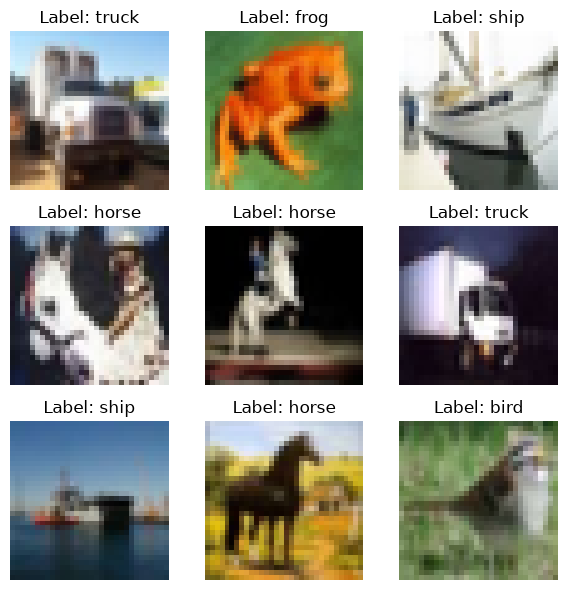

In [35]:
# 학습 데이터셋에서 9개의 이미지를 시각화합니다.
show_multiple_images(trainloader)

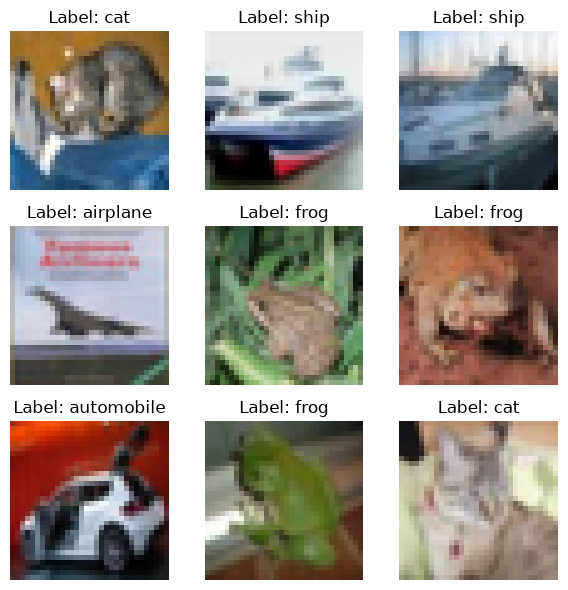

In [36]:
# 테스트 데이터셋에서 9개의 이미지를 시각화합니다.
show_multiple_images(testloader)

In [37]:
import torch
import torch.nn as nn

# Basic Residual Block (ResNet34) (used in ResNet-18/34)
class BasicBlock(nn.Module):
    expansion = 1   # Output channel multiplier
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        # First convolution layer
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        # Second convolution layer
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Downsample layer (used when dimensions change)
        self.downsample = downsample

    def forward(self, x):
        identity = x    # Save input for residual connection
        if self.downsample is not None:
            identity = self.downsample(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        # Add residual connection
        out += identity
        out = self.relu(out)

        return out


# Bottleneck Residual Block (ResNet50) (used in ResNet-50/101/152)
class BottleneckBlock(nn.Module):
    expansion = 4   # Output channel multiplier
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(BottleneckBlock, self).__init__()
        # 1x1 convolution (reduce dimensions)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)

        # 3x3 convolution (spatial convolution)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # 1x1 convolution (restore dimensions)
        self.conv3 = nn.Conv2d(out_channels, out_channels * self.expansion,
                               kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)

        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample

    def forward(self, x):
        identity = x    # Save input for residual connection
        if self.downsample is not None:
            identity = self.downsample(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        # Add residual connection
        out += identity
        out = self.relu(out)

        return out

# ResNet 공통 클래스
class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes=10):  # CIFAR-10 기본값
        super(ResNet, self).__init__()
        self.in_channels = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or self.in_channels != out_channels * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels * block.expansion,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * block.expansion),
            )

        layers = []
        # First block may require downsampling
        layers.append(block(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels * block.expansion

        # Remaining blocks
        for _ in range(1, blocks):
            layers.append(block(self.in_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        # Initial layers
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        # Residual layers
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        # Classification head
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        
        return x

In [38]:
# ResNet34 클래스
class build_resnet34(ResNet):
    def __init__(self, num_classes=10):
        super(build_resnet34, self).__init__(BasicBlock, [3, 4, 6, 3], num_classes)


# ResNet50 클래스
class build_resnet50(ResNet):
    def __init__(self, num_classes=10):
        super(build_resnet50, self).__init__(BottleneckBlock, [3, 4, 6, 3], num_classes)


In [39]:
# 블록 1개짜리 ResNet34
class ResNet34_oneblock(nn.Module):
    def __init__(self):
        super(ResNet34_oneblock, self).__init__()
        self.block = BasicBlock(in_channels=3, out_channels=64,
                                stride=1,
                                downsample=nn.Sequential(
                                    nn.Conv2d(3, 64, kernel_size=1, stride=1, bias=False),
                                    nn.BatchNorm2d(64)
                                ))

    def forward(self, x):
        return self.block(x)


# 블록 1개짜리 ResNet50
class ResNet50_oneblock(nn.Module):
    def __init__(self):
        super(ResNet50_oneblock, self).__init__()
        self.block = BottleneckBlock(in_channels=3, out_channels=64,
                                     stride=1,
                                     downsample=nn.Sequential(
                                         nn.Conv2d(3, 64*BottleneckBlock.expansion,
                                                   kernel_size=1, stride=1, bias=False),
                                         nn.BatchNorm2d(64*BottleneckBlock.expansion)
                                     ))

    def forward(self, x):
        return self.block(x)

In [40]:
# ResNet-34
resnet_34 = build_resnet34()
summary(resnet_34, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
build_resnet34                           [1, 10]                   --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 64, 56, 56]           --
│    └─BasicBlock: 2-1                   [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-6                    [1, 64, 56, 56]           --
│

In [41]:
# ResNet-50
resnet_50 = build_resnet50()
summary(resnet_50, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
build_resnet50                           [1, 10]                   --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 256, 56, 56]          --
│    └─BottleneckBlock: 2-1              [1, 256, 56, 56]          --
│    │    └─Sequential: 3-1              [1, 256, 56, 56]          16,896
│    │    └─Conv2d: 3-2                  [1, 64, 56, 56]           4,096
│    │    └─BatchNorm2d: 3-3             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-4                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-5                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-6             [1, 64, 56, 56]           12

In [ ]:
BATCH_SIZE = 256
EPOCH = 20

In [43]:
# CIFAR-10 데이터셋에 대해 Normalize와 Tensor 변환을 적용하는 코드
transform = transforms.Compose([
    transforms.ToTensor(),  # 이미지를 Tensor로 변환
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # VGG-16 표준 정규화
])

#########################################################################################################################
## Is path exists? If not, download the dataset
download_flag = not os.path.exists(train_path)
trainset = torchvision.datasets.CIFAR10(root=data_path, train=True, download=download_flag, transform=transform)
testset = torchvision.datasets.CIFAR10(root=data_path, train=False, download=download_flag, transform=transform)

# # Download CIFAR-10 dataset
# # Way 1
# trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
# testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# # Way 2 Manually download the dataset from https://www.cs.toronto.edu/~kriz/cifar.html and extract it to the data folder
# !mkdir -p data
# !wget --no-check-certificate https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz -O ./data/cifar-10-python.tar.gz
# !cd data && tar -xzf cifar-10-python.tar.gz
##########################################################################################################################

trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)
testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False)

In [44]:
current_time = time.time()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

###################################################################################
# ResNet34 모델 불러오기 (pretrained 인자 대신 weights 사용)
# resnet34 = torchvision.models.resnet34(pretrained=True)
resnet34 = torchvision.models.resnet34(weights=torchvision.models.ResNet34_Weights.DEFAULT)
resnet34.to(device)
###################################################################################

# 모든 파라미터 학습 가능하게 설정
for param in resnet34.parameters():
    param.requires_grad = True

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(resnet34.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

resnet34_train_losses = []
resnet34_val_accuracy = []

for epoch in range(EPOCH):
    resnet34.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (inputs, labels) in enumerate(trainloader, 0):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = resnet34(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if i % 100 == 99:
            print(f"[{epoch + 1}, {i + 1:5d}] loss: {running_loss / (i + 1):.3f}")
            
    train_loss = running_loss / len(trainloader)
    train_acc = 100 * correct / total
    resnet34_train_losses.append(train_loss)

    print(f"Epoch {epoch + 1}: Train Accuracy: {train_acc:.2f}%")

    resnet34.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = resnet34(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    resnet34_val_accuracy.append(val_acc)

    print(f"Epoch {epoch + 1}: Validation Accuracy: {val_acc:.2f}%")

print("Finished Training")
print(time.time() - current_time)

[1,   100] loss: 2.981
Epoch 1: Train Accuracy: 49.69%
Epoch 1: Validation Accuracy: 66.93%
[2,   100] loss: 0.833
Epoch 2: Train Accuracy: 72.29%
Epoch 2: Validation Accuracy: 73.41%
[3,   100] loss: 0.635
Epoch 3: Train Accuracy: 78.44%
Epoch 3: Validation Accuracy: 75.32%
[4,   100] loss: 0.503
Epoch 4: Train Accuracy: 82.57%
Epoch 4: Validation Accuracy: 76.85%
[5,   100] loss: 0.408
Epoch 5: Train Accuracy: 85.94%
Epoch 5: Validation Accuracy: 77.27%
[6,   100] loss: 0.314
Epoch 6: Train Accuracy: 88.85%
Epoch 6: Validation Accuracy: 77.53%
[7,   100] loss: 0.236
Epoch 7: Train Accuracy: 91.76%
Epoch 7: Validation Accuracy: 77.59%
[8,   100] loss: 0.175
Epoch 8: Train Accuracy: 93.93%
Epoch 8: Validation Accuracy: 77.64%
[9,   100] loss: 0.120
Epoch 9: Train Accuracy: 95.80%
Epoch 9: Validation Accuracy: 77.97%
[10,   100] loss: 0.090
Epoch 10: Train Accuracy: 97.16%
Epoch 10: Validation Accuracy: 77.77%
[11,   100] loss: 0.067
Epoch 11: Train Accuracy: 98.01%
Epoch 11: Validation

In [45]:
current_time = time.time()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

####################################################################################
# fixed the deprecation warning for pretrained argument in torchvision.models.resnet50
# resnet_50 = torchvision.models.resnet50(pretrained=True)
resnet50 = torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.DEFAULT)
resnet50.to(device)
#####################################################################################

# 모든 파라미터 학습 가능하게 설정
for param in resnet50.parameters():
    param.requires_grad = True

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(resnet50.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

resnet50_train_losses = []
resnet50_val_accuracy = []

for epoch in range(EPOCH):
    resnet50.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (inputs, labels) in enumerate(trainloader, 0):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = resnet50(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if i % 100 == 99:
            print(f"[{epoch + 1}, {i + 1:5d}] loss: {running_loss / (i + 1):.3f}")

    train_loss = running_loss / len(trainloader)
    resnet50_train_losses.append(train_loss)

    train_acc = 100 * correct / total
    print(f"Epoch {epoch + 1}: Train Accuracy: {train_acc:.2f}%")

    resnet50.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = resnet50(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    resnet50_val_accuracy.append(val_acc)

    print(f"Epoch {epoch + 1}: Validation Accuracy: {val_acc:.2f}%")

print("Finished Training")
print(time.time() - current_time)


[1,   100] loss: 6.962
Epoch 1: Train Accuracy: 4.35%
Epoch 1: Validation Accuracy: 10.58%
[2,   100] loss: 5.129
Epoch 2: Train Accuracy: 24.15%
Epoch 2: Validation Accuracy: 40.54%
[3,   100] loss: 1.951
Epoch 3: Train Accuracy: 47.94%
Epoch 3: Validation Accuracy: 53.51%
[4,   100] loss: 1.241
Epoch 4: Train Accuracy: 59.22%
Epoch 4: Validation Accuracy: 60.99%
[5,   100] loss: 0.997
Epoch 5: Train Accuracy: 66.84%
Epoch 5: Validation Accuracy: 64.63%
[6,   100] loss: 0.831
Epoch 6: Train Accuracy: 72.32%
Epoch 6: Validation Accuracy: 68.04%
[7,   100] loss: 0.703
Epoch 7: Train Accuracy: 76.57%
Epoch 7: Validation Accuracy: 69.45%
[8,   100] loss: 0.603
Epoch 8: Train Accuracy: 80.07%
Epoch 8: Validation Accuracy: 70.65%
[9,   100] loss: 0.517
Epoch 9: Train Accuracy: 83.23%
Epoch 9: Validation Accuracy: 71.13%
[10,   100] loss: 0.441
Epoch 10: Train Accuracy: 85.40%
Epoch 10: Validation Accuracy: 72.18%
[11,   100] loss: 0.373
Epoch 11: Train Accuracy: 87.86%
Epoch 11: Validation 

In [ ]:
plt.plot(resnet34_train_losses, 'r', label="ResNet-34 Training Loss")
plt.plot(resnet50_train_losses, 'b', label="ResNet-50 Training Loss")

plt.title('Model Training Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

In [ ]:
plt.plot(resnet34_val_accuracy, 'r', label="ResNet-34 Validation Accuracy")
plt.plot(resnet50_val_accuracy, 'b', label="ResNet-50 Validation Accuracy")

plt.title('Model Validation Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

In [ ]:
import torch
import numpy as np

print(torch.__version__)
print(np.__version__)